# Interactive Latent-to-Shape Visualization (MLP VAE)

This notebook loads the trained VAE + DeepSDF models for **real labels** and **pseudo labels** and lets you interactively adjust each latent dimension to see the output shape.

- Initial slider values are set to the mean of the saved 8D latents.
- Slider ranges are derived from the min/max of the saved latents.
- Use the **Render** button (or enable Auto Update) to regenerate the mesh.


In [43]:
import os
import json
import numpy as np
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from ipywidgets import (
    FloatSlider, IntSlider, Dropdown, Button, VBox, HBox, Label, Output, Checkbox
)
from IPython.display import display, clear_output, HTML
from skimage import measure
import trimesh

from networks import deep_sdf_decoder
from networks import residual_mlp_vae
import deep_sdf.workspace as ws
import deep_sdf.utils as sdf_utils
import train_MLP_VAE_deep_sdf as train_vae

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

try:
    import anywidget as _anywidget  # noqa: F401
    _HAS_ANYWIDGET = True
except Exception:
    _HAS_ANYWIDGET = False
    print("anywidget not found; view persistence disabled (install anywidget to keep camera view).")

try:
    import nbformat as _nbformat
    _HAS_NBFORMAT = True
except Exception:
    _HAS_NBFORMAT = False
    print("nbformat not found; using HTML renderer for Plotly.")

def display_plotly(fig):
    if _HAS_NBFORMAT:
        display(fig)
    else:
        display(HTML(fig.to_html(include_plotlyjs="cdn")))


Using device: cuda
anywidget not found; view persistence disabled (install anywidget to keep camera view).
nbformat not found; using HTML renderer for Plotly.


In [44]:
# Update these paths if your experiment folders are elsewhere.
EXPERIMENTS = {
    "real_label": "examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label_age",
    "pseudo_label": "examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_pseudo_label_only",
}

MODEL_FILENAME = "1000.pth"
LATENTS_FILENAME = "1000.pth"

In [45]:
def load_specs(exp_dir):
    specs_path = os.path.join(exp_dir, "specs.json")
    with open(specs_path, "r") as f:
        return json.load(f)


def build_models(specs):
    code_len = specs["CodeLength"]
    sdf_decoder = deep_sdf_decoder.Decoder(code_len, **specs["NetworkSpecs"])
    vae = residual_mlp_vae.ResidualMLPVAE(
        input_dim=specs.get("VAEInputDim", code_len),
        latent_dim=specs.get("VAELatentDim", 8),
        encoder_hidden_dims=specs.get("VAEEncoderHiddenDims", [256, 128]),
        decoder_hidden_dims=specs.get("VAEDecoderHiddenDims", [128, 256, 256]),
        num_blocks=specs.get("VAEBlocks", 1),
        activation=specs.get("VAEActivation", "gelu"),
        dropout=specs.get("VAEDropout", 0.0),
        use_layernorm=specs.get("VAELayerNorm", True),
        use_kl=specs.get("UseKLLoss", True),
    )
    return vae, sdf_decoder


def load_models(exp_dir, device):
    specs = load_specs(exp_dir)
    vae, sdf_decoder = build_models(specs)
    epoch = train_vae.load_model(exp_dir, MODEL_FILENAME, vae, sdf_decoder)
    vae.to(device).eval()
    sdf_decoder.to(device).eval()
    return specs, vae, sdf_decoder, epoch


def load_latents(exp_dir):
    latent_path = os.path.join(exp_dir, "LatentCodes", LATENTS_FILENAME)
    latents = train_vae.load_latent_codes_from_file(latent_path)
    if isinstance(latents, dict):
        keys = sorted(latents.keys())
        latents = torch.stack([latents[k] for k in keys], dim=0)
    if isinstance(latents, torch.Tensor):
        if latents.dim() == 3 and latents.size(1) == 1:
            latents = latents[:, 0, :]
        return latents.float()
    raise ValueError("Unexpected latent format")


def latent_stats(latents):
    minv = latents.min(dim=0).values
    maxv = latents.max(dim=0).values
    meanv = latents.mean(dim=0)
    return minv, maxv, meanv


def create_mesh_from_decoder(decoder, latent_vec, N=64, max_batch=32768, device="cuda", return_sdf=False):
    decoder.eval()
    voxel_origin = [-1.0, -1.0, -1.0]
    voxel_size = 2.0 / (N - 1)

    overall_index = torch.arange(0, N ** 3, 1, dtype=torch.long)
    samples = torch.zeros(N ** 3, 4)
    samples[:, 2] = overall_index % N
    samples[:, 1] = (overall_index.long() / N) % N
    samples[:, 0] = ((overall_index.long() / N) / N) % N

    samples[:, 0] = (samples[:, 0] * voxel_size) + voxel_origin[2]
    samples[:, 1] = (samples[:, 1] * voxel_size) + voxel_origin[1]
    samples[:, 2] = (samples[:, 2] * voxel_size) + voxel_origin[0]

    num_samples = N ** 3
    head = 0
    while head < num_samples:
        end = min(head + max_batch, num_samples)
        sample_subset = samples[head:end, 0:3].to(device)
        with torch.no_grad():
            pred = sdf_utils.decode_sdf(decoder, latent_vec, sample_subset)
            pred = pred.squeeze(1).detach().cpu()
        samples[head:end, 3] = pred
        head = end

    sdf_values = samples[:, 3].reshape(N, N, N).numpy()

    try:
        verts, faces, normals, _ = measure.marching_cubes(
            sdf_values, level=0.0, spacing=[voxel_size] * 3, method="lewiner"
        )
    except ValueError as exc:
        print(f"Marching cubes failed: {exc}")
        if return_sdf:
            return None, None, None, None
        return None

    mesh_points = np.zeros_like(verts)
    mesh_points[:, 0] = voxel_origin[0] + verts[:, 0]
    mesh_points[:, 1] = voxel_origin[1] + verts[:, 1]
    mesh_points[:, 2] = voxel_origin[2] + verts[:, 2]

    mesh = trimesh.Trimesh(vertices=mesh_points, faces=faces, vertex_normals=normals, process=False)
    if return_sdf:
        return mesh, sdf_values, np.array(voxel_origin), voxel_size
    return mesh


def latent_to_mesh(z, vae, sdf_decoder, device, grid_n=64, max_batch=32768, return_sdf=False):
    z_tensor = torch.tensor(z, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        z_hat = vae.decoder(z_tensor)
    return create_mesh_from_decoder(
        sdf_decoder, z_hat, N=grid_n, max_batch=max_batch, device=device, return_sdf=return_sdf
    )


def volume_from_sdf(sdf_values, voxel_size):
    if sdf_values is None or voxel_size is None:
        return None
    inside = sdf_values < 0
    return float(np.sum(inside)) * (voxel_size ** 3)


def intensity_from_diff_grid(mesh, diff_grid, voxel_origin, voxel_size):
    if mesh is None or diff_grid is None or voxel_origin is None or voxel_size is None:
        return None
    v = mesh.vertices
    idx = np.rint((v - voxel_origin) / voxel_size).astype(int)
    max_idx = np.array(diff_grid.shape) - 1
    idx = np.clip(idx, 0, max_idx)
    vals = diff_grid[idx[:, 0], idx[:, 1], idx[:, 2]]
    maxv = float(np.max(vals)) if vals.size else 0.0
    if maxv <= 1e-8:
        return np.zeros_like(vals)
    return vals / maxv


def _prepare_vertices(mesh, upright=False):
    v = mesh.vertices.copy()
    if upright:
        # Rotate +90 deg around X so Z becomes up (swap Y/Z).
        v = np.stack([v[:, 0], v[:, 2], -v[:, 1]], axis=1)
    return v


def build_dual_top_view_figure(base_mesh, change_mesh, title=None, upright=False, intensity=None):
    base_v = _prepare_vertices(base_mesh, upright=upright)
    base_f = base_mesh.faces
    change_v = _prepare_vertices(change_mesh, upright=upright)
    change_f = change_mesh.faces

    fig = make_subplots(
        rows=2, cols=1,
        specs=[[{'type': 'scene'}], [{'type': 'scene'}]],
        vertical_spacing=0.02,
        subplot_titles=('Base Shape', 'Change Map'),
    )

    fig.add_trace(
        go.Mesh3d(
            x=base_v[:, 0], y=base_v[:, 1], z=base_v[:, 2],
            i=base_f[:, 0], j=base_f[:, 1], k=base_f[:, 2],
            color='skyblue', opacity=1.0,
        ),
        row=1, col=1
    )

    if intensity is None:
        intensity = np.zeros(change_v.shape[0], dtype=np.float32)
    fig.add_trace(
        go.Mesh3d(
            x=change_v[:, 0], y=change_v[:, 1], z=change_v[:, 2],
            i=change_f[:, 0], j=change_f[:, 1], k=change_f[:, 2],
            intensity=intensity,
            colorscale=[[0.0, '#FFF9C4'], [1.0, '#FFC107']],
            cmin=0.0, cmax=1.0,
            showscale=False,
            opacity=1.0,
        ),
        row=2, col=1
    )

    fig.update_layout(
        title=title,
        margin=dict(l=0, r=0, b=0, t=30),
        scene_aspectmode='data',
        scene2_aspectmode='data',
        scene_camera=dict(eye=dict(x=0.0, y=0.0, z=2.8)),
        scene2_camera=dict(eye=dict(x=0.0, y=0.0, z=2.8)),
        uirevision='keep',
    )
    fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
    if _HAS_ANYWIDGET:
        return go.FigureWidget(fig)
    return fig


def update_dual_top_view_figure(fig, intensity=None, title=None):
    if intensity is None:
        intensity = np.zeros(fig.data[1].x.shape[0], dtype=np.float32)
    change_trace = fig.data[1]
    with fig.batch_update():
        change_trace.intensity = intensity
        change_trace.colorscale = [[0.0, '#FFF9C4'], [1.0, '#FFC107']]
        change_trace.cmin = 0.0
        change_trace.cmax = 1.0
        change_trace.showscale = False
        if title is not None:
            fig.layout.title = title
    return fig


    base_trace = fig.data[0]
    change_trace = fig.data[1]
    with fig.batch_update():
        base_trace.x = base_v[:, 0]
        base_trace.y = base_v[:, 1]
        base_trace.z = base_v[:, 2]
        base_trace.i = base_f[:, 0]
        base_trace.j = base_f[:, 1]
        base_trace.k = base_f[:, 2]
        base_trace.color = 'skyblue'
        base_trace.opacity = 1.0

        change_trace.x = change_v[:, 0]
        change_trace.y = change_v[:, 1]
        change_trace.z = change_v[:, 2]
        change_trace.i = change_f[:, 0]
        change_trace.j = change_f[:, 1]
        change_trace.k = change_f[:, 2]
        change_trace.intensity = intensity
        change_trace.colorscale = [[0.0, '#FFF9C4'], [1.0, '#FFC107']]
        change_trace.cmin = 0.0
        change_trace.cmax = 1.0
        change_trace.showscale = False
        change_trace.opacity = 1.0
        if title is not None:
            fig.layout.title = title
    return fig


    if change_mesh is None:
        change_mesh = base_mesh
        intensity = None
        change_opacity = 0.0
    else:
        change_opacity = 0.7 if intensity is not None else 0.0

    change_v = _prepare_vertices(change_mesh, upright=upright)
    change_f = change_mesh.faces
    change_trace = fig.data[1]

    with fig.batch_update():
        base_trace.x = base_v[:, 0]
        base_trace.y = base_v[:, 1]
        base_trace.z = base_v[:, 2]
        base_trace.i = base_f[:, 0]
        base_trace.j = base_f[:, 1]
        base_trace.k = base_f[:, 2]
        base_trace.color = 'skyblue'
        base_trace.opacity = 1.0

        change_trace.x = change_v[:, 0]
        change_trace.y = change_v[:, 1]
        change_trace.z = change_v[:, 2]
        change_trace.i = change_f[:, 0]
        change_trace.j = change_f[:, 1]
        change_trace.k = change_f[:, 2]
        change_trace.opacity = change_opacity
        if intensity is None:
            change_trace.intensity = None
            change_trace.colorscale = None
            change_trace.color = '#FFC107'
        else:
            change_trace.color = None
            change_trace.intensity = intensity
            change_trace.colorscale = [[0.0, '#FFF9C4'], [1.0, '#FFC107']]
            change_trace.cmin = 0.0
            change_trace.cmax = 1.0
            change_trace.showscale = False
        if title is not None:
            fig.layout.title = title
    return fig



In [46]:
experiments = {}
for name, exp_dir in EXPERIMENTS.items():
    if not os.path.isdir(exp_dir):
        print(f"Missing experiment dir: {exp_dir}")
        continue
    specs, vae, sdf_decoder, epoch = load_models(exp_dir, device)
    latents = load_latents(exp_dir)
    minv, maxv, meanv = latent_stats(latents)
    experiments[name] = {
        "exp_dir": exp_dir,
        "specs": specs,
        "vae": vae,
        "sdf_decoder": sdf_decoder,
        "epoch": epoch,
        "latent_dim": latents.shape[1],
        "minv": minv,
        "maxv": maxv,
        "meanv": meanv,
    }

print(f"Loaded experiments: {list(experiments.keys())}")


Loaded experiments: ['real_label', 'pseudo_label']


In [47]:
def _slider_step(minv, maxv):
    span = float(maxv - minv)
    if span <= 0:
        return 0.01
    return span / 200.0


def build_experiment_ui(name, exp, default_grid=None):
    latent_dim = exp["latent_dim"]
    minv = exp["minv"]
    maxv = exp["maxv"]
    meanv = exp["meanv"]

    sliders = []
    for i in range(latent_dim):
        #if i == 0:
            #zmin = -10.0
            #zmax = 10.0
        #else:
        zmin = float(minv[i].item())
        zmax = float(maxv[i].item())
        step = _slider_step(zmin, zmax)
        slider = FloatSlider(
            value=float(meanv[i].item()),
            min=zmin,
            max=zmax,
            step=step,
            description=f"z{i}",
            continuous_update=False,
            readout_format=".4f",
            layout={"width": "350px"},
        )
        sliders.append(slider)

    if default_grid is None:
        default_grid = 64 if device.type == "cuda" else 32

    grid_slider = IntSlider(
        value=default_grid,
        min=32,
        max=128,
        step=16,
        description="Grid N",
        continuous_update=False,
        layout={"width": "350px"},
    )
    batch_slider = IntSlider(
        value=32768 if device.type == "cuda" else 8192,
        min=8192,
        max=131072,
        step=8192,
        description="Max batch",
        continuous_update=False,
        layout={"width": "350px"},
    )

    auto_update = Checkbox(value=False, description="Auto update")
    upright = Checkbox(value=False, description="Upright mesh")
    render_btn = Button(description="Render", button_style="primary")
    reset_btn = Button(description="Reset to mean")

    out = Output()
    fig_widget = None
    base_mesh = None
    base_sdf = None
    base_origin = None
    base_voxel = None
    base_volume = None
    base_grid_n = None
    volume_label = Label(value="Volume: N/A")

    def render(_=None):
        nonlocal fig_widget, base_mesh, base_sdf, base_origin, base_voxel, base_volume, base_grid_n
        with out:
            clear_output(wait=True)
            mean_z = [float(v.item()) for v in meanv]
            grid_n = grid_slider.value
            # Ensure baseline mesh/SDF at mean latent and current grid resolution.
            if base_mesh is None or base_grid_n != grid_n:
                base_mesh, base_sdf, base_origin, base_voxel = latent_to_mesh(
                    mean_z, exp["vae"], exp["sdf_decoder"], device,
                    grid_n=grid_n, max_batch=batch_slider.value, return_sdf=True
                )
                base_volume = volume_from_sdf(base_sdf, base_voxel)
                base_grid_n = grid_n

            # Current mesh/SDF for current z.
            z = [s.value for s in sliders]
            mesh, cur_sdf, cur_origin, cur_voxel = latent_to_mesh(
                z, exp["vae"], exp["sdf_decoder"], device,
                grid_n=grid_n, max_batch=batch_slider.value, return_sdf=True
            )
            if mesh is None or base_mesh is None:
                print("No mesh generated (marching cubes failed).")
                return

            title = f"{name} (epoch {exp['epoch']})"
            intensity = None
            change_mesh = base_mesh
            if base_sdf is not None and cur_sdf is not None and base_sdf.shape == cur_sdf.shape:
                diff_grid = np.abs(cur_sdf - base_sdf)
                intensity = intensity_from_diff_grid(base_mesh, diff_grid, base_origin, base_voxel)

            if fig_widget is None:
                fig_widget = build_dual_top_view_figure(
                    base_mesh, change_mesh=change_mesh, title=title, intensity=intensity
                )
                display_plotly(fig_widget)
            else:
                update_dual_top_view_figure(fig_widget, intensity=intensity, title=title)
                if not _HAS_ANYWIDGET:
                    display_plotly(fig_widget)

            vol = volume_from_sdf(cur_sdf, cur_voxel)
            if vol is None:
                volume_label.value = "Volume: N/A"
            elif base_volume is None:
                volume_label.value = f"Volume: {vol:.4f}"
            else:
                dvol = vol - base_volume
                volume_label.value = f"Volume: {vol:.4f} (Δ {dvol:+.4f})"

    def on_slider_change(change):
        if auto_update.value:
            render()

    def on_reset(_):
        for i, s in enumerate(sliders):
            s.value = float(meanv[i].item())
        if auto_update.value:
            render()

    for s in sliders:
        s.observe(on_slider_change, names="value")
    grid_slider.observe(on_slider_change, names="value")
    batch_slider.observe(on_slider_change, names="value")
    render_btn.on_click(render)
    reset_btn.on_click(on_reset)

    controls = VBox(
        [
            Label(value=f"Experiment: {exp['exp_dir']}"),
            HBox([render_btn, reset_btn, auto_update, upright]),
            volume_label,
            grid_slider,
            batch_slider,
            VBox(sliders),
        ]
    )
    ui = VBox([controls, out])
    render()
    return ui


tabs_children = []
tab_titles = []
for name, exp in experiments.items():
    tabs_children.append(build_experiment_ui(name, exp))
    tab_titles.append(name)

if tabs_children:
    from ipywidgets import Tab
    tabs = Tab(children=tabs_children)
    for i, t in enumerate(tab_titles):
        tabs.set_title(i, t)
    display(tabs)
else:
    print("No experiments loaded. Check EXPERIMENTS paths.")


## Random 256D Latent Samples vs GT Mesh Volume (Real Label Model)
This section samples 10 latent codes (256D teacher latents), generates shapes, computes their volumes, and compares to the corresponding ground-truth mesh volumes.


In [48]:
import random
import pandas as pd
from deep_sdf import data as sdf_data

# Real-label experiment directory
REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
vae_real.eval()
sdf_dec_real.eval()

# Load 8D VAE latents (saved during VAE training)
latents_8d = load_latents(REAL_EXP)  # shape: [N, 8]
print('8D latents shape:', tuple(latents_8d.shape))

# Build dataset filenames list to align indices with latents
split_path = specs_real["TrainSplit"]
with open(split_path, 'r') as f:
    split_json = json.load(f)
npz_filenames = sdf_data.get_instance_filenames(specs_real["DataSource"], split_json)

# Load volumes from labels.pt (if available)
mesh_root = specs_real["DataSourceMesh"]
labels_path = os.path.join(mesh_root, 'labels.pt')
label_map = {}
if os.path.exists(labels_path):
    all_labels = torch.load(labels_path, map_location='cpu')
    if isinstance(all_labels, dict):
        label_map = all_labels
    elif hasattr(all_labels, '__len__') and len(all_labels) == len(npz_filenames):
        for idx, filename in enumerate(npz_filenames):
            base_name = os.path.splitext(os.path.basename(filename))[0]
            label_map[base_name] = all_labels[idx]
    else:
        print('Warning: labels.pt not dict and length mismatch; label lookup disabled.')
else:
    print(f'labels.pt not found at {labels_path}')

# Randomly pick 10 indices
indices = random.sample(range(len(latents_8d)), 10)

# Helper to map npz filename -> mesh path
mesh_ext = specs_real.get("EvalGTMeshExt", ".obj")
def npz_to_mesh_path(npz_path):
    base = os.path.splitext(npz_path)[0]
    base = base.lstrip(os.sep)
    return os.path.join(mesh_root, base + mesh_ext)

results = []
grid_n = 128
max_batch = 32768 if device.type == 'cuda' else 8192

for idx in indices:
    z8 = latents_8d[idx].to(device).unsqueeze(0)
    # 8D -> 256D via VAE decoder
    with torch.no_grad():
        z256 = vae_real.decoder(z8)
    # 256D -> shape via DeepSDF decoder
    mesh_pred, sdf_pred, origin, voxel = create_mesh_from_decoder(
        sdf_dec_real, z256, N=grid_n, max_batch=max_batch, device=device, return_sdf=True
    )
    pred_vol = volume_from_sdf(sdf_pred, voxel)

    # GT volume from labels.pt (if available)
    npz_path = npz_filenames[idx]
    base_name = os.path.splitext(os.path.basename(npz_path))[0]
    if base_name in label_map:
        gt_label = label_map[base_name]
        gt_vol = float(gt_label[3].item())
        diagnosis = int(gt_label[0].item())
        diagnosis_label = 'AD' if diagnosis == 1 else 'not AD'
    else:
        gt_vol = None
        diagnosis = None
        diagnosis_label = None
        gt_vol = None

    # Optional: mesh volume as a sanity check
    gt_mesh_path = npz_to_mesh_path(npz_path)
    if os.path.isfile(gt_mesh_path):
        gt_mesh = trimesh.load(gt_mesh_path, force='mesh')
        gt_mesh = sdf_utils.as_mesh(gt_mesh)
        gt_mesh_vol = float(gt_mesh.volume)
    else:
        gt_mesh_vol = None

    results.append({
        'index': idx,
        'npz': npz_path,
        'diagnosis': diagnosis,
        'diagnosis_label': diagnosis_label,
        'gt_volume_label': gt_vol,
        'gt_volume_mesh': gt_mesh_vol,
        'pred_volume': pred_vol,
    })

df = pd.DataFrame(results)
df


8D latents shape: (696, 8)


,index,npz,diagnosis,diagnosis_label,gt_volume_label,gt_volume_mesh,pred_volume
0,418,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,1956.333496,None,0.120431
1,169,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1810.904053,None,0.124129
2,11,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1305.744751,None,0.078142
3,669,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,2283.550049,None,0.139943
4,357,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,2630.531250,None,0.164707
5,278,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1939.140015,None,0.121266
6,253,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,1506.255005,None,0.093029
7,567,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,1849.112549,None,0.115084
8,551,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,1988.965942,None,0.121469
9,656,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1411.300049,None,0.088276


## 8D Latent Analysis: Correlation, Embeddings, and Clustering
This section analyzes the 8D VAE latents against diagnosis and volume using multiple methods (HLLE+ICA, ICA, NMF, PCA, FA) and clustering.


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Ensure 8D latents and labels are loaded
REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
latents_8d = load_latents(REAL_EXP)  # [N, 8]

# Build filenames list
split_path = specs_real["TrainSplit"]
with open(split_path, 'r') as f:
    split_json = json.load(f)
npz_filenames = sdf_data.get_instance_filenames(specs_real["DataSource"], split_json)

# Load labels from labels.pt
mesh_root = specs_real["DataSourceMesh"]
labels_path = os.path.join(mesh_root, 'labels.pt')
label_map = {}
if os.path.exists(labels_path):
    all_labels = torch.load(labels_path, map_location='cpu')
    if isinstance(all_labels, dict):
        label_map = all_labels
    elif hasattr(all_labels, '__len__') and len(all_labels) == len(npz_filenames):
        for idx, filename in enumerate(npz_filenames):
            base_name = os.path.splitext(os.path.basename(filename))[0]
            label_map[base_name] = all_labels[idx]
    else:
        print('Warning: labels.pt not dict and length mismatch; label lookup disabled.')
else:
    print(f'labels.pt not found at {labels_path}')

# Build diagnosis/volume arrays aligned with latents_8d
diagnosis = []
volume = []
age = []
for filename in npz_filenames:
    base = os.path.splitext(os.path.basename(filename))[0]
    if base in label_map:
        lab = label_map[base]
        diagnosis.append(int(lab[0].item()))
        volume.append(float(lab[3].item()))
        age.append(float(lab[1].item()))
    else:
        diagnosis.append(-1)
        volume.append(float('nan'))
        age.append(float(lab[1].item()))
diagnosis = np.array(diagnosis)
volume = np.array(volume, dtype=float)
age = np.array(age, dtype=float)

X = latents_8d.cpu().numpy()
print('Latents:', X.shape, 'Diagnosis:', diagnosis.shape, 'Volume:', volume.shape)


Latents: (696, 8) Diagnosis: (696,) Volume: (696,)


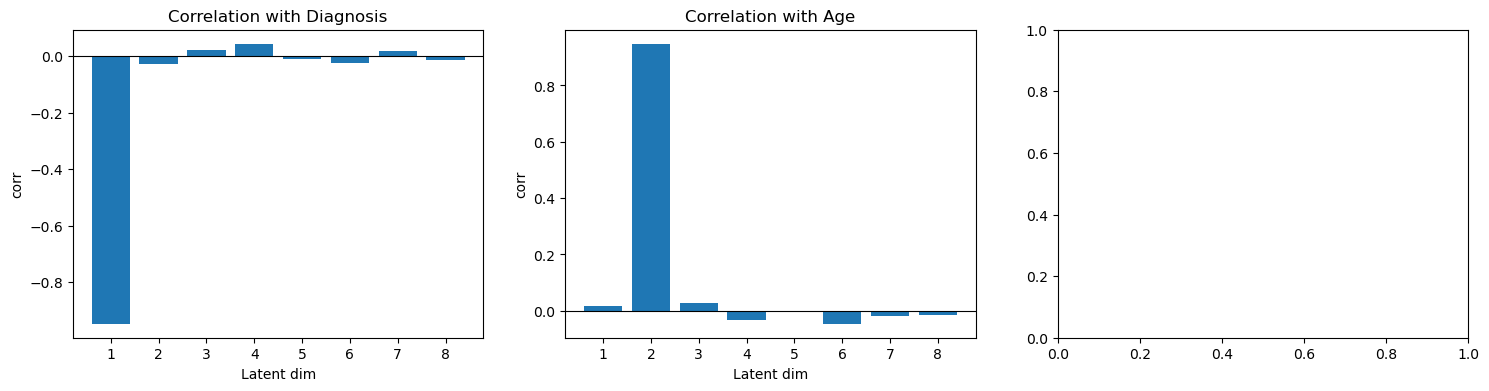

In [50]:
# Correlation per latent dimension with diagnosis and volume
corr_diag = []
corr_age = []
corr_vol = []
for d in range(X.shape[1]):
    # diagnosis correlation (mask valid)
    mask_d = diagnosis >= 0
    if np.any(mask_d):
        corr = np.corrcoef(X[mask_d, d], diagnosis[mask_d])[0, 1]
    else:
        corr = float('nan')
    corr_diag.append(corr)
    # age correlation (mask finite)
    mask_a = np.isfinite(age)
    if np.any(mask_a):
        corr = np.corrcoef(X[mask_a, d], age[mask_a])[0, 1]
    else:
        corr = float('nan')
    corr_age.append(corr)
    # volume correlation (mask finite)
    mask_v = np.isfinite(volume)
    if np.any(mask_v):
        corr = np.corrcoef(X[mask_v, d], volume[mask_v])[0, 1]
    else:
        corr = float('nan')
    corr_vol.append(corr)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(range(1, 9), corr_diag)
axes[0].set_title('Correlation with Diagnosis')
axes[0].set_xlabel('Latent dim')
axes[0].set_ylabel('corr')
axes[0].axhline(0, color='k', linewidth=0.8)

axes[1].bar(range(1, 9), corr_age)
axes[1].set_title('Correlation with Age')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('corr')
axes[1].axhline(0, color='k', linewidth=0.8)



HLLE+ICA failed: for method='hessian', n_neighbors must be greater than [n_components * (n_components + 3) / 2]


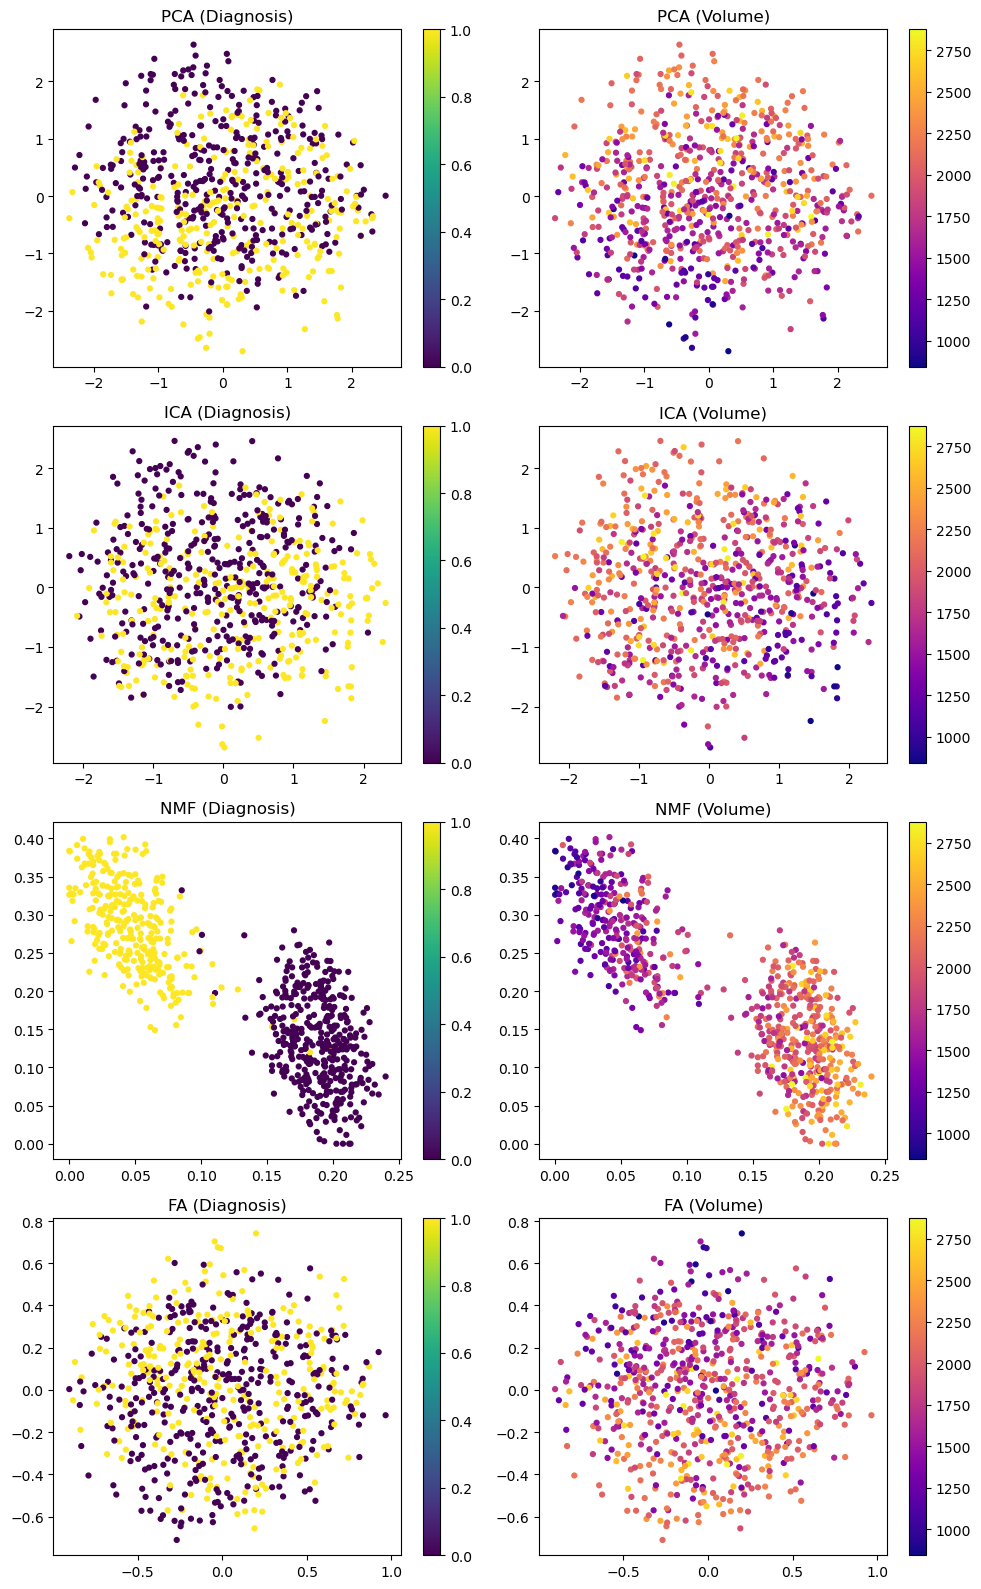

In [51]:
# Embeddings: PCA, ICA, NMF, FA, HLLE+ICA
X_std = StandardScaler().fit_transform(X)

results = {}

# PCA
pca = PCA(n_components=2)
results['PCA'] = pca.fit_transform(X_std)

# ICA
ica = FastICA(n_components=2, random_state=0)
results['ICA'] = ica.fit_transform(X_std)

# NMF (requires non-negative)
X_nn = MinMaxScaler().fit_transform(X)
nmf = NMF(n_components=2, init='nndsvda', random_state=0, max_iter=500)
results['NMF'] = nmf.fit_transform(X_nn)

# Factor Analysis
fa = FactorAnalysis(n_components=2, random_state=0)
results['FA'] = fa.fit_transform(X_std)

# HLLE + ICA (HLLE to 6D, then ICA to 2D)
try:
    hlle = LocallyLinearEmbedding(n_neighbors=10, n_components=6, method='hessian', eigen_solver='dense')
    Y_hlle = hlle.fit_transform(X_std)
    ica2 = FastICA(n_components=2, random_state=0)
    results['HLLE+ICA'] = ica2.fit_transform(Y_hlle)
except Exception as e:
    print('HLLE+ICA failed:', e)

# Plot embeddings colored by diagnosis and volume
fig, axes = plt.subplots(len(results), 2, figsize=(10, 4 * len(results)))
if len(results) == 1:
    axes = np.array([axes])
for i, (name, Y) in enumerate(results.items()):
    mask_d = diagnosis >= 0
    ax = axes[i, 0]
    sc = ax.scatter(Y[mask_d, 0], Y[mask_d, 1], c=diagnosis[mask_d], cmap='viridis', s=12)
    ax.set_title(f'{name} (Diagnosis)')
    plt.colorbar(sc, ax=ax)
    mask_v = np.isfinite(volume)
    ax = axes[i, 1]
    sc = ax.scatter(Y[mask_v, 0], Y[mask_v, 1], c=volume[mask_v], cmap='plasma', s=12)
    ax.set_title(f'{name} (Volume)')
    plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()


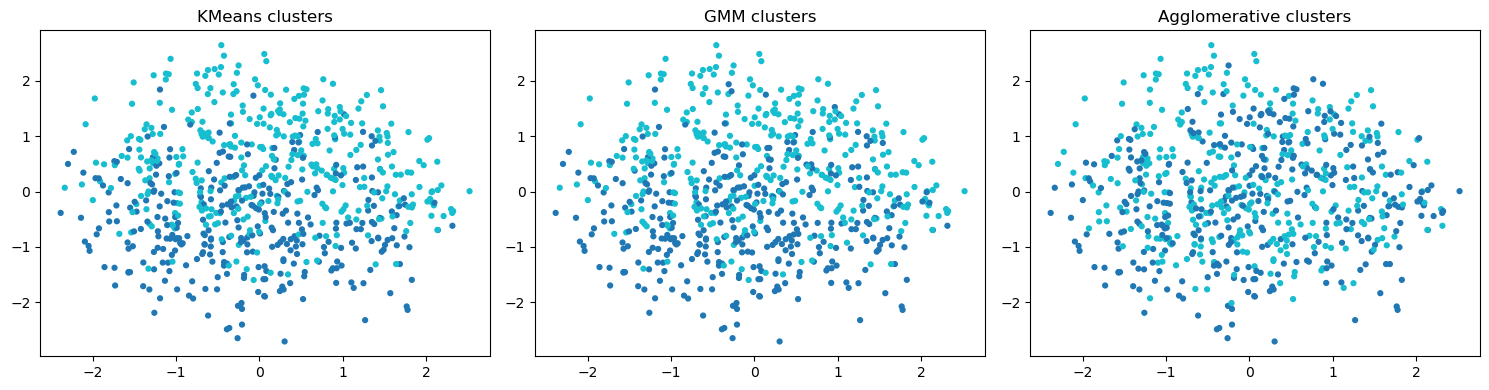

In [52]:
# Clustering on 8D latents
Xc = StandardScaler().fit_transform(X)

cluster_results = {}
cluster_results['KMeans'] = KMeans(n_clusters=2, random_state=0).fit_predict(Xc)
cluster_results['GMM'] = GaussianMixture(n_components=2, random_state=0).fit_predict(Xc)
cluster_results['Agglomerative'] = AgglomerativeClustering(n_clusters=2).fit_predict(Xc)

# Plot cluster assignments on PCA embedding
Y_pca = PCA(n_components=2).fit_transform(Xc)
fig, axes = plt.subplots(1, len(cluster_results), figsize=(5 * len(cluster_results), 4))
if len(cluster_results) == 1:
    axes = [axes]
for ax, (name, labels) in zip(axes, cluster_results.items()):
    sc = ax.scatter(Y_pca[:, 0], Y_pca[:, 1], c=labels, cmap='tab10', s=12)
    ax.set_title(f'{name} clusters')
plt.tight_layout()
plt.show()


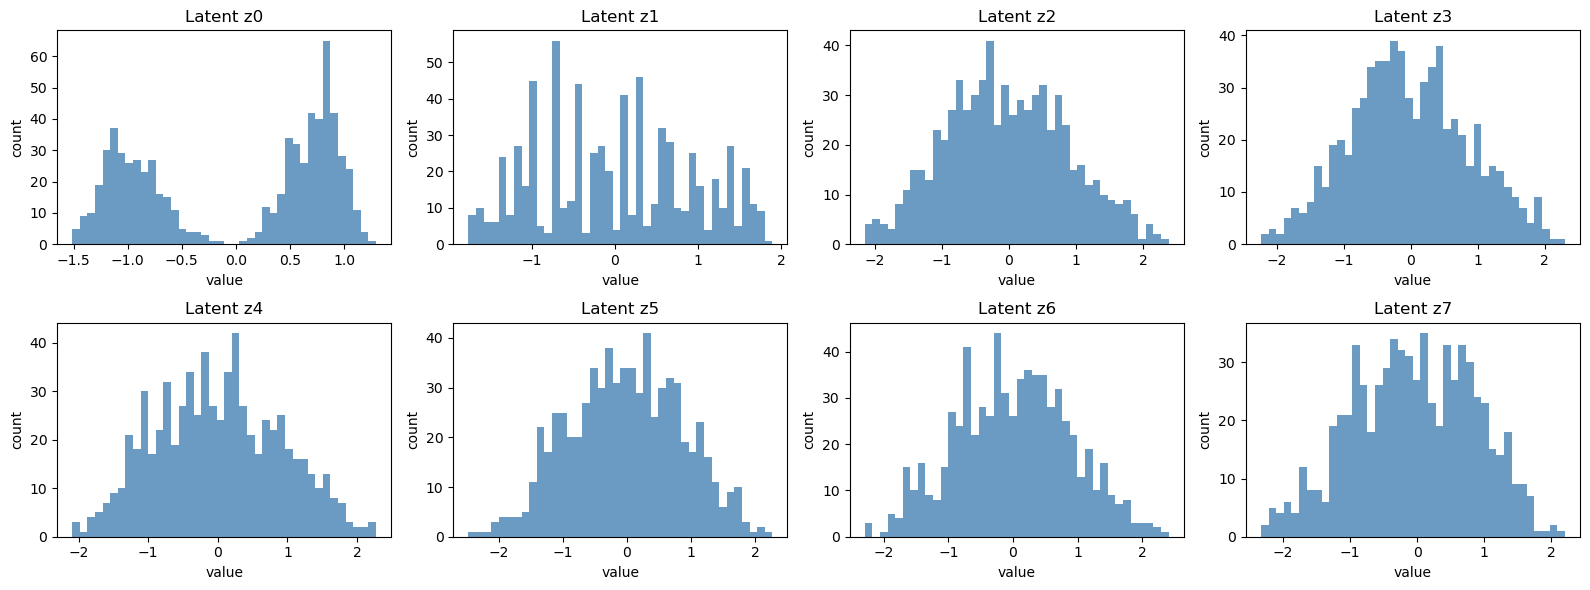

In [53]:
# Latent distributions for each of 8 variables
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i in range(8):
    ax = axes[i]
    ax.hist(X[:, i], bins=40, color='steelblue', alpha=0.8)
    ax.set_title(f'Latent z{i}')
    ax.set_xlabel('value')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()


## 8D Latent Analysis (Pseudo-Label Model, Real Labels for Analysis)
This repeats the 8D analysis for the **pseudo-label model**, but uses **real labels (labels.pt)** for diagnosis/volume.


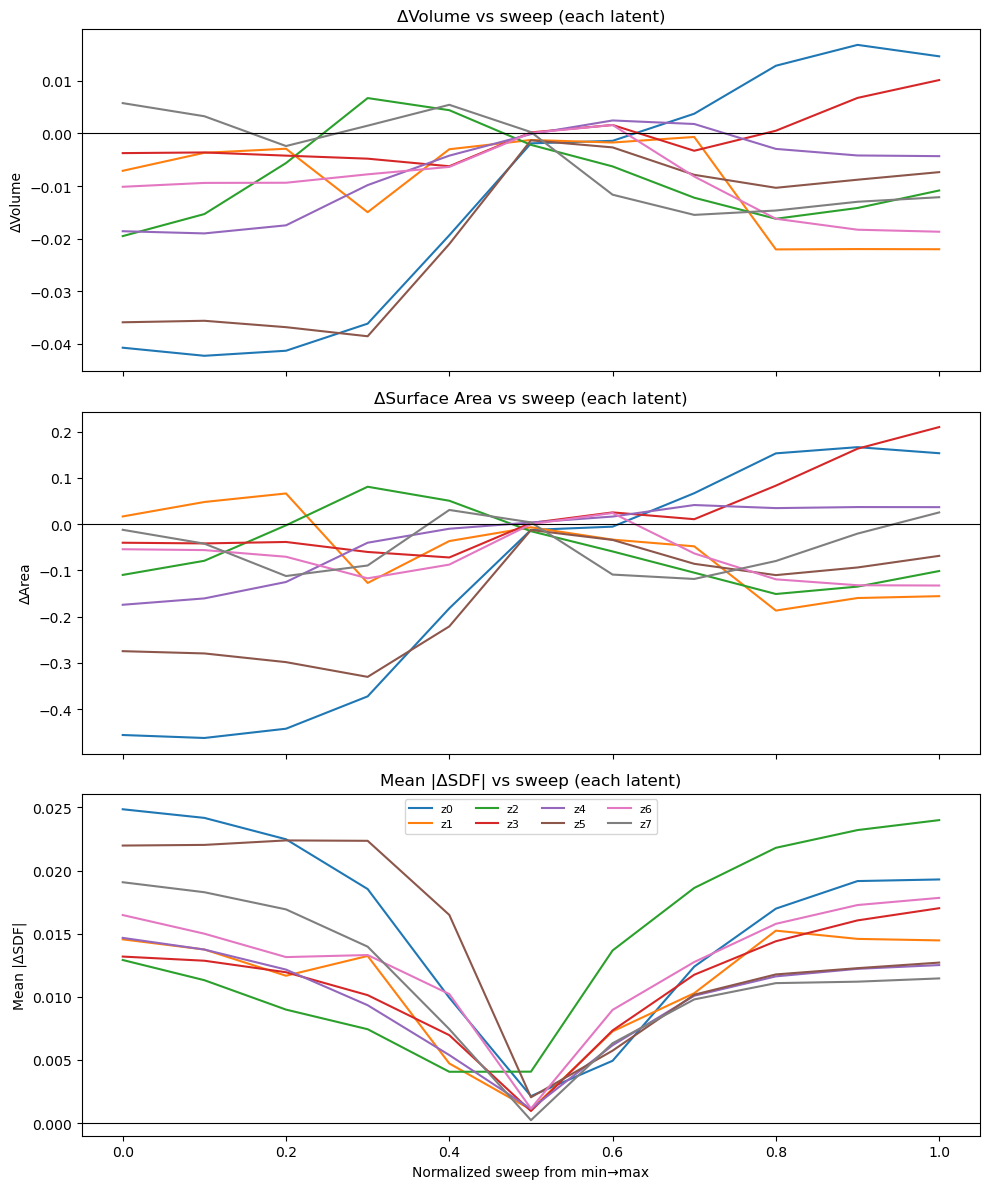

In [54]:
# Sweep each latent one-by-one: Δvolume, Δsurface area, mean|ΔSDF|
import numpy as np
import matplotlib.pyplot as plt

# Use real-label model
REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
vae_real.eval()
sdf_dec_real.eval()

# Load 8D latents and compute mean + range
latents_8d = load_latents(REAL_EXP)
minv, maxv, meanv = latent_stats(latents_8d)
mean_z = meanv.cpu().numpy()

grid_n = 64
max_batch = 32768 if device.type == 'cuda' else 8192

# Baseline at mean
base_mesh, base_sdf, base_origin, base_voxel = latent_to_mesh(
    mean_z, vae_real, sdf_dec_real, device, grid_n=grid_n, max_batch=max_batch, return_sdf=True
)
base_vol = volume_from_sdf(base_sdf, base_voxel)
base_area = float(base_mesh.area) if base_mesh is not None else None

sweep_pts = 11
zs = np.linspace(0.0, 1.0, sweep_pts)

delta_vol = []
delta_area = []
delta_sdf = []

for d in range(8):
    dv = []
    da = []
    ds = []
    zmin = float(minv[d].item())
    zmax = float(maxv[d].item())
    for t in zs:
        z = mean_z.copy()
        z[d] = zmin + t * (zmax - zmin)
        mesh, sdf, origin, voxel = latent_to_mesh(
            z, vae_real, sdf_dec_real, device, grid_n=grid_n, max_batch=max_batch, return_sdf=True
        )
        vol = volume_from_sdf(sdf, voxel)
        area = float(mesh.area) if mesh is not None else None
        if base_sdf is not None and sdf is not None and base_sdf.shape == sdf.shape:
            ds.append(float(np.mean(np.abs(sdf - base_sdf))))
        else:
            ds.append(float('nan'))
        dv.append(vol - base_vol if (vol is not None and base_vol is not None) else float('nan'))
        da.append(area - base_area if (area is not None and base_area is not None) else float('nan'))
    delta_vol.append(dv)
    delta_area.append(da)
    delta_sdf.append(ds)

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for d in range(8):
    axes[0].plot(zs, delta_vol[d], label=f'z{d}')
axes[0].set_title('ΔVolume vs sweep (each latent)')
axes[0].set_ylabel('ΔVolume')
axes[0].axhline(0, color='k', linewidth=0.8)

for d in range(8):
    axes[1].plot(zs, delta_area[d], label=f'z{d}')
axes[1].set_title('ΔSurface Area vs sweep (each latent)')
axes[1].set_ylabel('ΔArea')
axes[1].axhline(0, color='k', linewidth=0.8)

for d in range(8):
    axes[2].plot(zs, delta_sdf[d], label=f'z{d}')
axes[2].set_title('Mean |ΔSDF| vs sweep (each latent)')
axes[2].set_ylabel('Mean |ΔSDF|')
axes[2].set_xlabel('Normalized sweep from min→max')
axes[2].axhline(0, color='k', linewidth=0.8)

axes[2].legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


In [55]:
# Latent stats + suggested sweep ranges (mean ± 3*std)
latents_8d = load_latents(EXPERIMENTS["real_label"])
meanv = latents_8d.mean(dim=0)
stdv = latents_8d.std(dim=0)
minv = latents_8d.min(dim=0).values
maxv = latents_8d.max(dim=0).values

print('dim | min | max | mean | std | mean±3std')
for d in range(latents_8d.shape[1]):
    m = float(meanv[d])
    s = float(stdv[d])
    mn = float(minv[d])
    mx = float(maxv[d])
    lo = m - 3*s
    hi = m + 3*s
    print(f'z{d}: {mn:+.4f} {mx:+.4f} {m:+.4f} {s:.4f}  [{lo:+.4f}, {hi:+.4f}]')

# Flag near-collapsed dims
tiny = (stdv < 1e-3).cpu().numpy()
print('Near-constant dims (std<1e-3):', np.where(tiny)[0].tolist())


dim | min | max | mean | std | mean±3std
z0: -1.5122 +1.2934 -0.0019 0.8744  [-2.6251, +2.6213]
z1: -1.7671 +1.8955 -0.0063 0.9237  [-2.7772, +2.7647]
z2: -2.1456 +2.3770 -0.0324 0.9017  [-2.7375, +2.6727]
z3: -2.2388 +2.3022 -0.0218 0.8822  [-2.6683, +2.6247]
z4: -2.0907 +2.2714 +0.0044 0.8946  [-2.6794, +2.6883]
z5: -2.4763 +2.2686 -0.0215 0.8815  [-2.6660, +2.6230]
z6: -2.2941 +2.4061 +0.0066 0.8893  [-2.6613, +2.6745]
z7: -2.3294 +2.1997 -0.0535 0.9030  [-2.7625, +2.6556]
Near-constant dims (std<1e-3): []


In [56]:
# Test decoder sensitivity: Δcode for z0 vs z1 on a real sample
import numpy as np

REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
vae_real.eval()

latents_8d = load_latents(REAL_EXP)

# pick a real sample (not mean)
idx = np.random.randint(0, latents_8d.shape[0])
z = latents_8d[idx].to(device).float()
print('Using sample idx:', idx)

def delta_code(z, dim, delta):
    z_plus = z.clone()
    z_minus = z.clone()
    z_plus[dim] += delta
    z_minus[dim] -= delta
    with torch.no_grad():
        c_plus = vae_real.decoder(z_plus.unsqueeze(0))
        c_minus = vae_real.decoder(z_minus.unsqueeze(0))
    return float(torch.norm(c_plus - c_minus, p=2).item())

deltas = [0.01, 0.05, 0.1, 0.2, 0.5]

print('Δcode(z0):')
for d in deltas:
    print(f'  Δ={d:.3f} -> {delta_code(z, 0, d):.6f}')

print('Δcode(z1):')
for d in deltas:
    print(f'  Δ={d:.3f} -> {delta_code(z, 1, d):.6f}')

# ratio at Δ=0.1 (if both computed)
try:
    dc0 = delta_code(z, 0, 0.1)
    dc1 = delta_code(z, 1, 0.1)
    print(f'Ratio Δcode(z0)/Δcode(z1) at Δ=0.1: {dc0/dc1:.4f}')
except Exception as e:
    print('Ratio compute failed:', e)


Using sample idx: 472
Δcode(z0):
  Δ=0.010 -> 0.014626
  Δ=0.050 -> 0.073051
  Δ=0.100 -> 0.145602
  Δ=0.200 -> 0.287408
  Δ=0.500 -> 0.665775
Δcode(z1):
  Δ=0.010 -> 0.016137
  Δ=0.050 -> 0.080513
  Δ=0.100 -> 0.159990
  Δ=0.200 -> 0.312202
  Δ=0.500 -> 0.678135
Ratio Δcode(z0)/Δcode(z1) at Δ=0.1: 0.9101


In [41]:
from tensorboard.backend.event_processing import event_accumulator

path = "/home/jakaria/INR/Deep3DComp/examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label/TensorBoard/events.out.tfevents.1769638023.aot.2701693.0"
ea = event_accumulator.EventAccumulator(path)
ea.Reload()

for tag in ["Metric/train_sensitivity_delta", "Loss/train_sensitivity"]:
    if tag in ea.Tags().get("scalars", []):
        events = ea.Scalars(tag)
        print(tag, "count", len(events))
        for ep in [100, 200, 400, 600, 800]:
            vals = [e.value for e in events if e.step == ep]
            print("  ep", ep, vals[0] if vals else None)
    else:
        print(tag, "missing")


Metric/train_sensitivity_delta count 2000
  ep 100 0.01867530681192875
  ep 200 0.0206997562199831
  ep 400 0.016835907474160194
  ep 600 0.01403067447245121
  ep 800 0.01240281667560339
Loss/train_sensitivity count 2000
  ep 100 0.0
  ep 200 0.0
  ep 400 0.0
  ep 600 0.0
  ep 800 0.0


## Compare `labels.pt` vs `normalized_labels.pt` (age + consistency)
This block loads the files from the spec, checks key/name alignment, compares non-age fields, and verifies age normalization on random samples.


In [57]:
import os, json, random
import torch
import numpy as np

spec_path = 'examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label_age/specs.json'
with open(spec_path, 'r') as f:
    specs = json.load(f)

data_source = specs['DataSource']
labels_file = specs.get('LabelsFile', 'labels.pt')

raw_labels_path = os.path.join(data_source, 'labels.pt')
norm_labels_path = os.path.join(data_source, labels_file)

print('Raw labels:', raw_labels_path)
print('Normalized labels:', norm_labels_path)

raw_labels = torch.load(raw_labels_path)
norm_labels = torch.load(norm_labels_path)

# Helpers

def as_tensor(x):
    if isinstance(x, torch.Tensor):
        return x
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x)
    if isinstance(x, (list, tuple)):
        return torch.tensor(x)
    return None

# Try to coerce labels to dict form

def to_dict(obj):
    if isinstance(obj, dict):
        return obj
    return None

raw_dict = to_dict(raw_labels)
norm_dict = to_dict(norm_labels)

if raw_dict is None or norm_dict is None:
    print('labels.pt or normalized_labels.pt is not a dict; cannot compare by name.')
else:
    raw_keys = set(raw_dict.keys())
    norm_keys = set(norm_dict.keys())
    print('Total in labels.pt:', len(raw_keys))
    print('Total in normalized_labels.pt:', len(norm_keys))
    print('Missing in normalized_labels.pt:', len(raw_keys - norm_keys))
    print('Missing in labels.pt:', len(norm_keys - raw_keys))

    common_keys = sorted(raw_keys & norm_keys)
    print('Common keys:', len(common_keys))

    # Detect age field
    def extract_age(val):
        # If dict with age-like keys
        if isinstance(val, dict):
            for k in ['age', 'Age', 'AGE']:
                if k in val:
                    return float(val[k]), ('dict', k)
        t = as_tensor(val)
        if t is None:
            return None, None
        t = t.flatten()
        if t.numel() >= 2:
            return float(t[1].item()), ('index', 1)
        return None, None

    # Determine age position from a sample
    sample_key = common_keys[0] if common_keys else None
    age_idx = None
    age_mode = None
    if sample_key is not None:
        age_raw, meta = extract_age(raw_dict[sample_key])
        if meta:
            age_mode = meta[0]
            if meta[0] == 'index':
                age_idx = meta[1]
        print('Age detection mode:', meta)
    else:
        print('No common keys to compare.')

    # Compare non-age fields (e.g., diagnosis) when tensors are available
    mismatch_other = 0
    checked_other = 0
    for k in common_keys:
        rv = as_tensor(raw_dict[k])
        nv = as_tensor(norm_dict[k])
        if rv is None or nv is None:
            continue
        rv = rv.flatten()
        nv = nv.flatten()
        if rv.numel() != nv.numel() or rv.numel() == 0:
            continue
        if age_idx is not None and age_idx < rv.numel():
            mask = torch.ones(rv.numel(), dtype=torch.bool)
            mask[age_idx] = False
            if mask.any():
                checked_other += 1
                if not torch.allclose(rv[mask], nv[mask], atol=1e-6, rtol=1e-6):
                    mismatch_other += 1
        else:
            # No age index detected; skip other-field compare
            pass

    if checked_other:
        print(f'Non-age field mismatches: {mismatch_other} / {checked_other}')

    # Build age arrays for normalization check
    ages = []
    norm_ages = []
    for k in common_keys:
        a, _ = extract_age(raw_dict[k])
        b, _ = extract_age(norm_dict[k])
        if a is None or b is None:
            continue
        ages.append(a)
        norm_ages.append(b)

    if ages:
        ages = np.array(ages, dtype=float)
        norm_ages = np.array(norm_ages, dtype=float)
        min_age, max_age = ages.min(), ages.max()
        denom = max_age - min_age if max_age > min_age else 1.0
        calc_norm = (ages - min_age) / denom

        # Print summary of normalization error
        err = np.abs(calc_norm - norm_ages)
        print('Age min/max:', min_age, max_age)
        print('Normalization abs error: mean={:.6f}, max={:.6f}'.format(err.mean(), err.max()))

        # Show 20 random examples
        sample_n = min(20, len(common_keys))
        sample_keys = random.sample(common_keys, sample_n)
        print('\nSample comparisons (name, age_raw, age_norm_file, age_norm_calc):')
        for k in sample_keys:
            a, _ = extract_age(raw_dict[k])
            b, _ = extract_age(norm_dict[k])
            if a is None or b is None:
                continue
            c = (a - min_age) / denom
            print(f'{k}: age={a:.4f}, norm_file={b:.4f}, norm_calc={c:.4f}')
    else:
        print('Could not extract ages from label files.')


Raw labels: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/sdf_data/SdfSamples/minimal_scaled_obj_files/labels.pt
Normalized labels: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/sdf_data/SdfSamples/minimal_scaled_obj_files/normalized_labels.pt
Total in labels.pt: 1632
Total in normalized_labels.pt: 1632
Missing in normalized_labels.pt: 0
Missing in labels.pt: 0
Common keys: 1632
Age detection mode: ('index', 1)
Non-age field mismatches: 0 / 1632
Age min/max: 55.0 91.0
Normalization abs error: mean=0.000000, max=0.000000

Sample comparisons (name, age_raw, age_norm_file, age_norm_calc):
ADNI_099_S_0533_MR_Hippocampal_Mask_Hi_20080229145608107_S14938_I94506_left: age=81.0000, norm_file=0.7222, norm_calc=0.7222
ADNI_067_S_0176_MR_Hippocampal_Mask_Hi_20080229101459689_S24106_I94208_left: age=76.0000, norm_file=0.5833, norm_calc=0.5833
ADNI_128_S_1043_MR_Hippocampal_Mask_Hi_20090701132936157_S22562_I147585_left: age=69.0000, norm_file=0.

In [58]:
import os, json
import torch

spec_path = 'examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label_age/specs.json'
with open(spec_path, 'r') as f:
    specs = json.load(f)

data_source = specs['DataSource']
labels_file = specs.get('LabelsFile', 'labels.pt')

raw_labels_path = os.path.join(data_source, 'labels.pt')
norm_labels_path = os.path.join(data_source, labels_file)

raw_labels = torch.load(raw_labels_path)
norm_labels = torch.load(norm_labels_path)

print('Raw labels first 20:')
if isinstance(raw_labels, dict):
    for k in sorted(raw_labels.keys())[:20]:
        print(k, raw_labels[k])
else:
    for i, v in enumerate(raw_labels[:20]):
        print(i, v)

print('Normalized labels first 20:')
if isinstance(norm_labels, dict):
    for k in sorted(norm_labels.keys())[:20]:
        print(k, norm_labels[k])
else:
    for i, v in enumerate(norm_labels[:20]):
        print(i, v)


Raw labels first 20:
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111448800_S13408_I93328_left tensor([   0.0000,   85.0000,    0.0000, 1995.9200])
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111508581_S21856_I93329_left tensor([   0.0000,   85.0000,    0.0000, 2010.5260])
ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111524597_S32678_I93331_left tensor([   0.0000,   86.0000,    0.0000, 2144.1555])
ADNI_002_S_0413_MR_Hippocampal_Mask_Hi_20090630133420824_S13893_I146878_left tensor([0.0000e+00, 7.6000e+01, 1.0000e+00, 2.0955e+03])
ADNI_002_S_0413_MR_Hippocampal_Mask_Hi_20090630133440731_S22557_I146879_left tensor([0.0000e+00, 7.7000e+01, 1.0000e+00, 2.2126e+03])
ADNI_002_S_0413_MR_Hippocampal_Mask_Hi_20090630133455856_S32938_I146880_left tensor([0.0000e+00, 7.7000e+01, 1.0000e+00, 2.0557e+03])
ADNI_002_S_0619_MR_Hippocampal_Mask_Hi_20080228111542738_S15145_I93333_left tensor([1.0000e+00, 7.8000e+01, 0.0000e+00, 1.7132e+03])
ADNI_002_S_0619_MR_Hippocampal_Mask_Hi_20080228111602660_

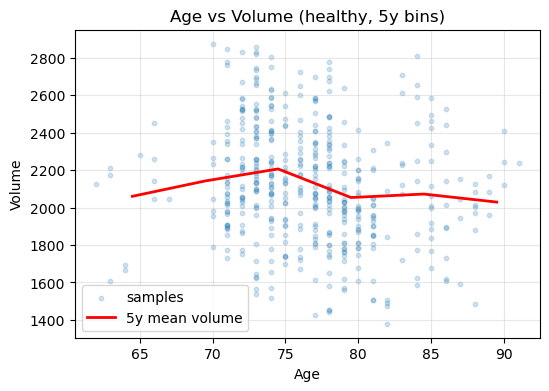

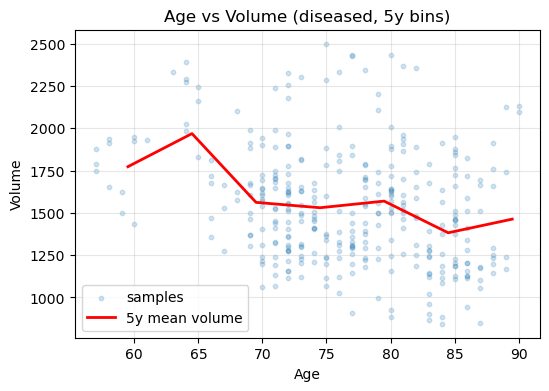

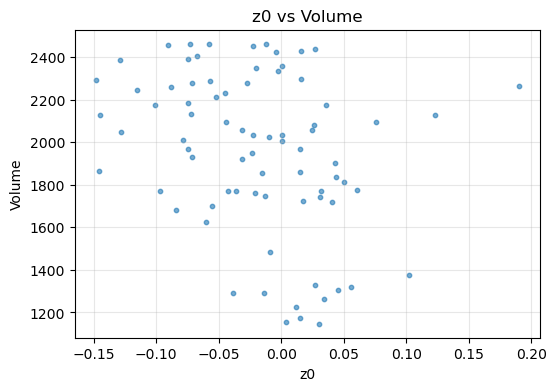

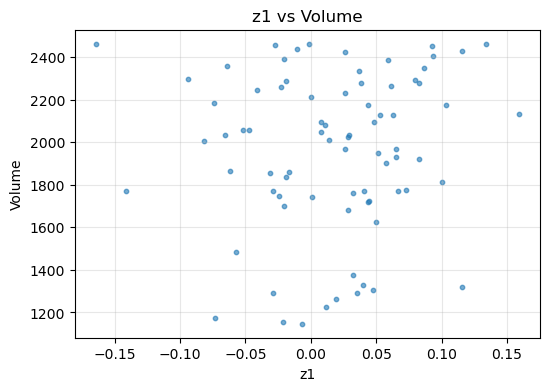

Corr(age, volume)= -0.19518177363589445
Corr(z0, volume)= -0.29945794550572363
Corr(z1, volume)= 0.07733904107107106


In [61]:
import os, json
import torch
import numpy as np
import matplotlib.pyplot as plt

spec_path = 'examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label_age/specs.json'
with open(spec_path, 'r') as f:
    specs = json.load(f)

data_source = specs['DataSource']
labels_file = specs.get('LabelsFile', 'labels.pt')

raw_labels_path = os.path.join(data_source, 'labels.pt')
labels_path = os.path.join(data_source, labels_file)

raw_labels = torch.load(raw_labels_path)
labels = torch.load(labels_path)

# Expect dict: name -> tensor([disease, age, volume?])
if not isinstance(raw_labels, dict) or not isinstance(labels, dict):
    print('labels.pt or normalized_labels.pt is not a dict; cannot plot by name.')
else:
    # Load latents if available from latest export (optional)
    # This assumes you have latents exported to a dict name->latent vector.
    latent_path = specs.get('TestLatentPath', None)
    latents = None
    if latent_path and os.path.exists(os.path.join(os.path.dirname(spec_path), latent_path)):
        try:
            latents = torch.load(os.path.join(os.path.dirname(spec_path), latent_path))
        except Exception:
            latents = None

    # Extract age and volume (raw) from labels.pt
    names = sorted(raw_labels.keys())
    ages = []
    volumes = []
    z0 = []
    z1 = []

    for name in names:
        rv = raw_labels[name]
        if isinstance(rv, torch.Tensor):
            rv = rv.flatten()
            if rv.numel() < 3:
                continue
            age = float(rv[1].item())
            vol = float(rv[-1].item())
        elif isinstance(rv, (list, tuple, np.ndarray)):
            rv = np.array(rv).reshape(-1)
            if rv.size < 3:
                continue
            age = float(rv[1])
            vol = float(rv[-1])
        else:
            continue
        ages.append(age)
        volumes.append(vol)

        if latents is not None and isinstance(latents, dict) and name in latents:
            zv = latents[name]
            if isinstance(zv, torch.Tensor):
                zv = zv.flatten()
                if zv.numel() >= 2:
                    z0.append(float(zv[0].item()))
                    z1.append(float(zv[1].item()))
                else:
                    z0.append(np.nan)
                    z1.append(np.nan)
            else:
                z0.append(np.nan)
                z1.append(np.nan)
        else:
            z0.append(np.nan)
            z1.append(np.nan)

    ages = np.array(ages)
    volumes = np.array(volumes)
    z0 = np.array(z0)
    z1 = np.array(z1)


    
    # Mean volume per 5-year age bins, split by disease label (index 0)
    disease = []
    for name in names:
        rv = raw_labels[name]
        if isinstance(rv, torch.Tensor):
            rv = rv.flatten()
            if rv.numel() < 2:
                disease.append(np.nan)
                continue
            disease.append(float(rv[0].item()))
        elif isinstance(rv, (list, tuple, np.ndarray)):
            rv = np.array(rv).reshape(-1)
            if rv.size < 2:
                disease.append(np.nan)
                continue
            disease.append(float(rv[0]))
        else:
            disease.append(np.nan)
    disease = np.array(disease)

    def plot_group(mask, title):
        if mask.sum() < 2:
            print(f'Not enough samples for {title}')
            return
        a = ages[mask]
        v = volumes[mask]
        # 5-year bins starting from floor(min age) to ceil(max age)
        age_min = np.floor(a.min())
        age_max = np.ceil(a.max())
        bins = np.arange(age_min, age_max + 5, 5)
        bin_centers = (bins[:-1] + bins[1:]) / 2.0
        mean_vol = []
        for lo, hi in zip(bins[:-1], bins[1:]):
            sel = (a >= lo) & (a < hi)
            if sel.any():
                mean_vol.append(v[sel].mean())
            else:
                mean_vol.append(np.nan)
        mean_vol = np.array(mean_vol)

        plt.figure(figsize=(6,4))
        plt.scatter(a, v, s=10, alpha=0.2, label='samples')
        plt.plot(bin_centers, mean_vol, color='red', linewidth=2, label='5y mean volume')
        plt.xlabel('Age')
        plt.ylabel('Volume')
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    # Assuming disease labels are 0/1
    plot_group(disease == 0, 'Age vs Volume (healthy, 5y bins)')
    plot_group(disease == 1, 'Age vs Volume (diseased, 5y bins)')


    # Volume vs z0/z1 if latents present
    if np.isfinite(z0).any():
        plt.figure(figsize=(6,4))
        plt.scatter(z0, volumes, s=10, alpha=0.6)
        plt.xlabel('z0')
        plt.ylabel('Volume')
        plt.title('z0 vs Volume')
        plt.grid(True, alpha=0.3)
        plt.show()

    if np.isfinite(z1).any():
        plt.figure(figsize=(6,4))
        plt.scatter(z1, volumes, s=10, alpha=0.6)
        plt.xlabel('z1')
        plt.ylabel('Volume')
        plt.title('z1 vs Volume')
        plt.grid(True, alpha=0.3)
        plt.show()

    # Simple correlation summaries
    def safe_corr(a, b):
        mask = np.isfinite(a) & np.isfinite(b)
        if mask.sum() < 2:
            return np.nan
        return np.corrcoef(a[mask], b[mask])[0,1]

    print('Corr(age, volume)=', safe_corr(ages, volumes))
    print('Corr(z0, volume)=', safe_corr(z0, volumes))
    print('Corr(z1, volume)=', safe_corr(z1, volumes))


Computing volume curve for z0 = min...
Computing volume curve for z0 = max...


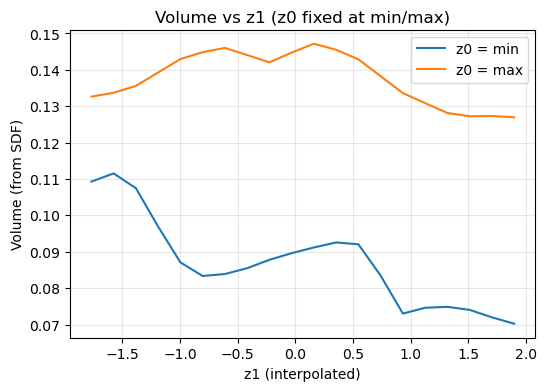

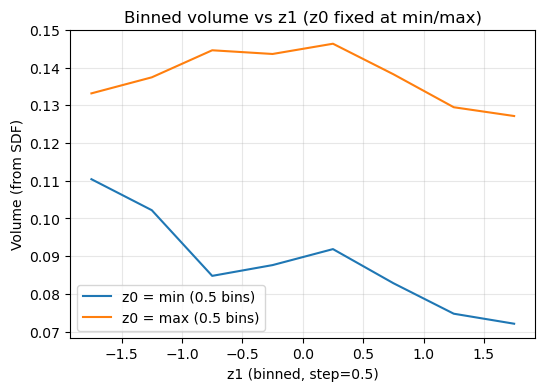

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Volume from SDF (shape) while sweeping z1; z0 fixed at min/max, others at mean
REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
latents_8d = load_latents(REAL_EXP)
minv, maxv, meanv = latent_stats(latents_8d)

z0_min = float(minv[0].item())
z0_max = float(maxv[0].item())
z1_min = float(minv[1].item())
z1_max = float(maxv[1].item())

z1_grid = np.linspace(z1_min, z1_max, 20)

grid_n = 64  # increase to 128 for higher fidelity (slower)
max_batch = 32768


def volume_curve(z0_fixed):
    vols = []
    for z1_val in z1_grid:
        z = meanv.clone()
        z[0] = z0_fixed
        z[1] = float(z1_val)
        mesh, sdf_vals, voxel_origin, voxel_size = latent_to_mesh(
            z.tolist(), vae_real, sdf_dec_real, device, grid_n=grid_n, max_batch=max_batch, return_sdf=True
        )
        vol = volume_from_sdf(sdf_vals, voxel_size)
        vols.append(vol)
    return np.array(vols, dtype=float)

print('Computing volume curve for z0 = min...')
vol_min = volume_curve(z0_min)
print('Computing volume curve for z0 = max...')
vol_max = volume_curve(z0_max)

plt.figure(figsize=(6,4))
plt.plot(z1_grid, vol_min, label='z0 = min')
plt.plot(z1_grid, vol_max, label='z0 = max')
plt.xlabel('z1 (interpolated)')
plt.ylabel('Volume (from SDF)')
plt.title('Volume vs z1 (z0 fixed at min/max)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Bin z1 in 0.5 steps and plot binned means
bin_step = 0.5
z1_bins = np.arange(np.floor(z1_min), np.ceil(z1_max) + bin_step, bin_step)
bin_centers = (z1_bins[:-1] + z1_bins[1:]) / 2.0

def bin_means(x, y, bins):
    out = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        sel = (x >= lo) & (x < hi)
        out.append(np.mean(y[sel]) if np.any(sel) else np.nan)
    return np.array(out)

vol_min_b = bin_means(z1_grid, vol_min, z1_bins)
vol_max_b = bin_means(z1_grid, vol_max, z1_bins)

plt.figure(figsize=(6,4))
plt.plot(bin_centers, vol_min_b, label='z0 = min (0.5 bins)')
plt.plot(bin_centers, vol_max_b, label='z0 = max (0.5 bins)')
plt.xlabel('z1 (binned, step=0.5)')
plt.ylabel('Volume (from SDF)')
plt.title('Binned volume vs z1 (z0 fixed at min/max)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



train split:
  total: 626 missing labels: 0
  disease (AD/CN) counts: {0.0: 358, 1.0: 268}
  age: min=0.06 max=1.00 mean=0.60 std=0.16
  sex counts: {0.0: 307, 1.0: 319}

validation split:
  total: 70 missing labels: 0
  disease (AD/CN) counts: {0.0: 35, 1.0: 35}
  age: min=0.11 max=0.92 mean=0.61 std=0.17
  sex counts: {0.0: 30, 1.0: 40}

test split:
  total: 77 missing labels: 0
  disease (AD/CN) counts: {0.0: 51, 1.0: 26}
  age: min=0.14 max=0.97 mean=0.61 std=0.19
  sex counts: {0.0: 41, 1.0: 36}


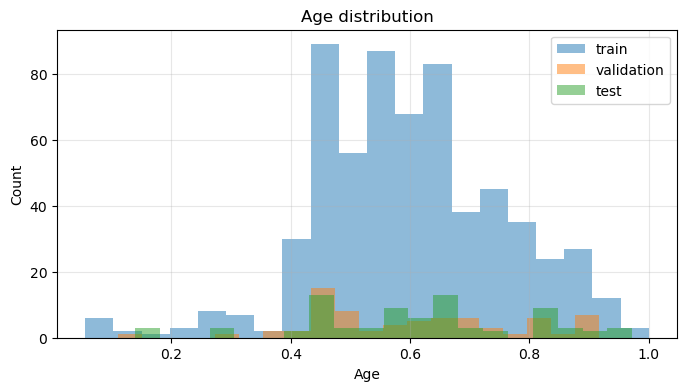

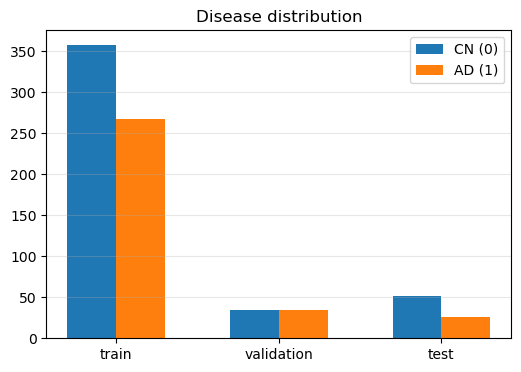

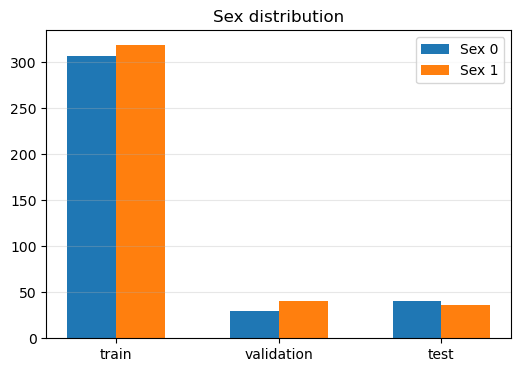

In [1]:
# Split distribution check (train / validation / test)
import os, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt

# Point this to the experiment you want to analyze
SPEC_PATH = 'examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label_age_latent_subset/specs.json'
DISEASE_LABEL_INDEX = 0
AGE_LABEL_INDEX = 1
SEX_LABEL_INDEX = 2  # adjust if your labels use a different index

def _load_split_list(path):
    with open(path, 'r') as f:
        data = json.load(f)
    if isinstance(data, list):
        return data
    # common dict formats
    for key in ['files', 'npyfiles', 'split', 'train', 'test']:
        if key in data and isinstance(data[key], list):
            return data[key]
    # fallback: all values if dict of lists
    for v in data.values():
        if isinstance(v, list):
            return v
    raise ValueError(f'Unrecognized split file format: {path}')

def _base(name):
    return os.path.splitext(os.path.basename(name))[0]

with open(SPEC_PATH, 'r') as f:
    specs = json.load(f)

data_source = specs['DataSource']
labels_file = specs.get('LabelsFile', 'labels.pt')
labels_path = os.path.join(data_source, labels_file)
labels = torch.load(labels_path)
if not isinstance(labels, dict):
    raise ValueError('labels.pt must be a dict name->label vector for this analysis')

train_split_path = specs['TrainSplit']
test_split_path = specs.get('TestSplit', None)

train_list = _load_split_list(train_split_path)
test_list = _load_split_list(test_split_path) if test_split_path else []

# Validation split from TrainLatentHoldoutFraction (same as training script)
holdout_frac = float(specs.get('TrainLatentHoldoutFraction', 0.0))
holdout_seed = int(specs.get('TrainLatentHoldoutSeed', 0))
train_list = [p for p in train_list if _base(p) in labels]

val_list = []
if holdout_frac > 0.0:
    rng = random.Random(holdout_seed)
    idxs = list(range(len(train_list)))
    rng.shuffle(idxs)
    holdout_count = int(round(len(train_list) * holdout_frac))
    val_ids = set(idxs[:holdout_count])
    val_list = [train_list[i] for i in range(len(train_list)) if i in val_ids]
    train_list = [train_list[i] for i in range(len(train_list)) if i not in val_ids]

def _collect_labels(names):
    disease = []
    age = []
    sex = []
    missing = 0
    for name in names:
        key = _base(name)
        if key not in labels:
            missing += 1
            continue
        v = labels[key]
        if isinstance(v, torch.Tensor):
            v = v.flatten()
        else:
            v = torch.tensor(v).flatten()
        if v.numel() > DISEASE_LABEL_INDEX:
            disease.append(float(v[DISEASE_LABEL_INDEX].item()))
        if v.numel() > AGE_LABEL_INDEX:
            age.append(float(v[AGE_LABEL_INDEX].item()))
        if v.numel() > SEX_LABEL_INDEX:
            sex.append(float(v[SEX_LABEL_INDEX].item()))
    return np.array(disease), np.array(age), np.array(sex), missing

def _summarize_split(name, names):
    disease, age, sex, missing = _collect_labels(names)
    print(f'\n{name} split:')
    print('  total:', len(names), 'missing labels:', missing)
    if disease.size:
        vals, counts = np.unique(disease, return_counts=True)
        print('  disease (AD/CN) counts:', dict(zip(vals.tolist(), counts.tolist())))
    if age.size:
        print('  age: min={:.2f} max={:.2f} mean={:.2f} std={:.2f}'.format(
            float(age.min()), float(age.max()), float(age.mean()), float(age.std())))
    if sex.size:
        vals, counts = np.unique(sex, return_counts=True)
        print('  sex counts:', dict(zip(vals.tolist(), counts.tolist())))
    return disease, age, sex

train_d, train_a, train_s = _summarize_split('train', train_list)
val_d, val_a, val_s = _summarize_split('validation', val_list)
test_d, test_a, test_s = _summarize_split('test', test_list)

# Plot age distributions
plt.figure(figsize=(8,4))
if train_a.size: plt.hist(train_a, bins=20, alpha=0.5, label='train')
if val_a.size: plt.hist(val_a, bins=20, alpha=0.5, label='validation')
if test_a.size: plt.hist(test_a, bins=20, alpha=0.5, label='test')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot disease distribution
plt.figure(figsize=(6,4))
labels_split = ['train','validation','test']
vals0 = [np.sum(train_d==0), np.sum(val_d==0), np.sum(test_d==0)]
vals1 = [np.sum(train_d==1), np.sum(val_d==1), np.sum(test_d==1)]
x = np.arange(3)
plt.bar(x-0.15, vals0, width=0.3, label='CN (0)')
plt.bar(x+0.15, vals1, width=0.3, label='AD (1)')
plt.xticks(x, labels_split)
plt.title('Disease distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Plot sex distribution
plt.figure(figsize=(6,4))
vals0 = [np.sum(train_s==0), np.sum(val_s==0), np.sum(test_s==0)]
vals1 = [np.sum(train_s==1), np.sum(val_s==1), np.sum(test_s==1)]
plt.bar(x-0.15, vals0, width=0.3, label='Sex 0')
plt.bar(x+0.15, vals1, width=0.3, label='Sex 1')
plt.xticks(x, labels_split)
plt.title('Sex distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


Train latents: examples/ADNI_1_L_No_MCI/minimal_eikonal_cov_256D_no_lambda/LatentCodes/latest.pth
Test latents : examples/ADNI_1_L_No_MCI/minimal_eikonal_cov_256D_no_lambda/test_latents/test_latents.pt
Train shape: (1, 696, 256)
Test shape : (77, 256)

Train summary:
  global mean/std: -5.8072491810889915e-05 0.04990993067622185
  global min/max : -0.29198190569877625 0.2714158892631531
  per-dim mean abs: 0.0005736210732720792
  per-dim std avg : 0.04836767166852951

Test summary:
  global mean/std: -0.0010505144018679857 0.07078710198402405
  global min/max : -0.3096696138381958 0.28523796796798706
  per-dim mean abs: 0.013092629611492157
  per-dim std avg : 0.06798279285430908

Top mean-diff dims:
  z115: mean_diff=0.0494
  z74: mean_diff=-0.0459
  z81: mean_diff=-0.0432
  z26: mean_diff=-0.0425
  z138: mean_diff=0.0416
  z69: mean_diff=-0.0406
  z60: mean_diff=0.0404
  z65: mean_diff=0.0386
  z221: mean_diff=0.0367
  z127: mean_diff=0.0353

Top std-diff dims:
  z52: std_diff=-0.042

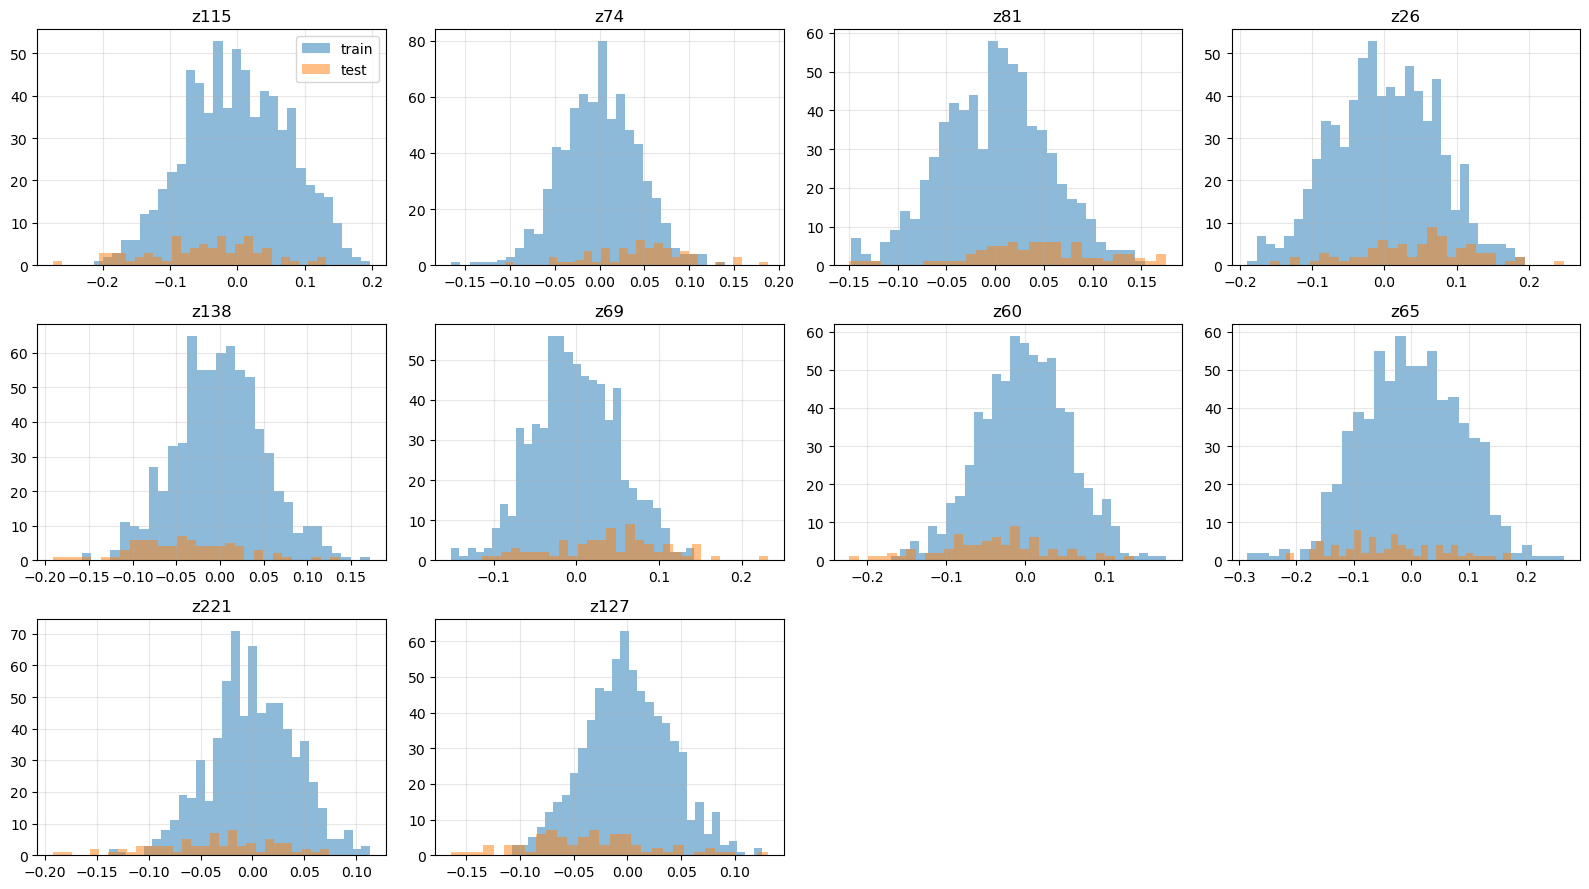

Label-based plots skipped: could not align latents with split lists.


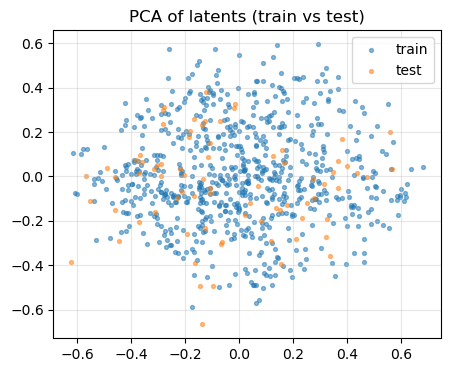

In [7]:
# Compare trained (train split) vs test latent distributions
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

SPEC_PATH = 'examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label_age_latent_subset/specs.json'

def _load_latents_any(path):
    obj = torch.load(path)
    if isinstance(obj, dict):
        # support dict of name->latent or dict with 'latent_codes'
        if 'latent_codes' in obj:
            obj = obj['latent_codes']
        if isinstance(obj, dict):
            keys = sorted(obj.keys())
            obj = torch.stack([obj[k] for k in keys], dim=0)
    if isinstance(obj, torch.Tensor):
        if obj.dim() == 3 and obj.size(1) == 1:
            obj = obj[:, 0, :]
        return obj.float()
    raise ValueError('Unrecognized latent format')

with open(SPEC_PATH, 'r') as f:
    specs = json.load(f)

exp_dir = os.path.dirname(SPEC_PATH)
train_latent_path = specs.get('PretrainedLatentPath', None)
test_latent_path = specs.get('TestLatentPath', None)
if train_latent_path is None or test_latent_path is None:
    print('Missing PretrainedLatentPath or TestLatentPath in specs.')
else:
    train_latent_path = os.path.normpath(os.path.join(exp_dir, train_latent_path))
    test_latent_path = os.path.normpath(os.path.join(exp_dir, test_latent_path))
    print('Train latents:', train_latent_path)
    print('Test latents :', test_latent_path)

    train_latents = _load_latents_any(train_latent_path)
    test_latents = _load_latents_any(test_latent_path)

    print('Train shape:', tuple(train_latents.shape))
    print('Test shape :', tuple(test_latents.shape))

    # Ensure 2D latents with correct latent_dim
    latent_dim = int(specs.get('CodeLength', specs.get('VAEInputDim', 256)))
    if train_latents.dim() != 2:
        if train_latents.dim() == 1 and train_latents.numel() % latent_dim == 0:
            train_latents = train_latents.view(-1, latent_dim)
        else:
            train_latents = train_latents.view(-1, train_latents.shape[-1])
    if test_latents.dim() != 2:
        if test_latents.dim() == 1 and test_latents.numel() % latent_dim == 0:
            test_latents = test_latents.view(-1, latent_dim)
        else:
            test_latents = test_latents.view(-1, test_latents.shape[-1])
    # If train/test latent dims mismatch, align to min dim
    if train_latents.shape[1] != test_latents.shape[1]:
        min_dim = min(train_latents.shape[1], test_latents.shape[1])
        print(f'Warning: latent dim mismatch {train_latents.shape[1]} vs {test_latents.shape[1]} -> using {min_dim}')
        train_latents = train_latents[:, :min_dim]
        test_latents = test_latents[:, :min_dim]

    # Summary stats (compact)
    def summarize(name, z):
        z_np = z.numpy()
        print(f'\n{name} summary:')
        print('  global mean/std:', float(z_np.mean()), float(z_np.std()))
        print('  global min/max :', float(z_np.min()), float(z_np.max()))
        print('  per-dim mean abs:', float(np.mean(np.abs(z_np.mean(axis=0)))))
        print('  per-dim std avg :', float(np.mean(z_np.std(axis=0))))

    summarize('Train', train_latents)
    summarize('Test', test_latents)

    # Mean/Std deltas per dim (top-k)
    mean_diff = (train_latents.mean(dim=0) - test_latents.mean(dim=0)).numpy()
    std_diff = (train_latents.std(dim=0) - test_latents.std(dim=0)).numpy()
    abs_mean_diff = np.abs(mean_diff)
    abs_std_diff = np.abs(std_diff)
    topk = min(10, abs_mean_diff.shape[0])
    top_mean_idx = np.argsort(-abs_mean_diff)[:topk]
    top_std_idx = np.argsort(-abs_std_diff)[:topk]
    print('\nTop mean-diff dims:')
    for i in top_mean_idx:
        print(f'  z{i}: mean_diff={mean_diff[i]:.4f}')
    print('\nTop std-diff dims:')
    for i in top_std_idx:
        print(f'  z{i}: std_diff={std_diff[i]:.4f}')

    # Aggregate distance metrics
    l2_mean = float(np.linalg.norm(mean_diff))
    l2_std = float(np.linalg.norm(std_diff))
    print('\nL2 distance of mean vectors:', l2_mean)
    print('L2 distance of std vectors :', l2_std)

    # Cosine similarity between mean vectors
    mean_train = train_latents.mean(dim=0)
    mean_test = test_latents.mean(dim=0)
    mean_train = mean_train.flatten()
    mean_test = mean_test.flatten()
    cos_sim = float((mean_train * mean_test).sum() / (mean_train.norm() * mean_test.norm() + 1e-8))
    print('Mean vector cosine similarity:', cos_sim)

    # Histograms for top-k dims only (overlay)
    topk_hist = min(12, top_mean_idx.shape[0])
    cols = 4
    rows = int(np.ceil(topk_hist / cols))
    plt.figure(figsize=(4*cols, 3*rows))
    for j, i in enumerate(top_mean_idx[:topk_hist]):
        plt.subplot(rows, cols, j+1)
        plt.hist(train_latents[:, i].numpy(), bins=30, alpha=0.5, label='train')
        plt.hist(test_latents[:, i].numpy(), bins=30, alpha=0.5, label='test')
        plt.title(f'z{i}')
        plt.grid(alpha=0.3)
        if j == 0:
            plt.legend()
    plt.tight_layout()
    plt.show()

    # Label-based comparison (AD vs CN) using label dict + split lists
    labels_file = specs.get('LabelsFile', 'labels.pt')
    labels_path = os.path.join(specs['DataSource'], labels_file)
    labels_dict = torch.load(labels_path)
    if isinstance(labels_dict, dict):
        # load split lists to align by name
        train_list = _load_split_list(specs['TrainSplit'])
        test_list = _load_split_list(specs.get('TestSplit', '')) if specs.get('TestSplit') else []

        def _collect_from_dict(latent_dict, names):
            zs = []
            ys = []
            for n in names:
                key = _base(n)
                if key not in latent_dict or key not in labels_dict:
                    continue
                z = latent_dict[key]
                if isinstance(z, torch.Tensor):
                    z = z.flatten()
                else:
                    z = torch.tensor(z).flatten()
                y = labels_dict[key]
                if isinstance(y, torch.Tensor):
                    y = y.flatten()
                else:
                    y = torch.tensor(y).flatten()
                if y.numel() <= DISEASE_LABEL_INDEX:
                    continue
                zs.append(z)
                ys.append(float(y[DISEASE_LABEL_INDEX].item()))
            if not zs:
                return None, None
            return torch.stack(zs, dim=0), np.array(ys, dtype=float)

        # try reloading latents as dict to keep names
        train_latents_raw = torch.load(train_latent_path)
        test_latents_raw = torch.load(test_latent_path)
        train_dict = train_latents_raw if isinstance(train_latents_raw, dict) else None
        test_dict = test_latents_raw if isinstance(test_latents_raw, dict) else None

        if train_dict is not None and test_dict is not None:
            z_train, y_train = _collect_from_dict(train_dict, train_list)
            z_test, y_test = _collect_from_dict(test_dict, test_list)

            if z_train is not None and z_test is not None:
                print('\nLabel-based analysis (AD vs CN)')
                print('  train samples:', z_train.shape[0], 'test samples:', z_test.shape[0])

                # choose top-k dims with largest mean diff between train/test
                mean_diff = (z_train.mean(dim=0) - z_test.mean(dim=0)).abs().numpy()
                topk = min(6, mean_diff.shape[0])
                top_idx = np.argsort(-mean_diff)[:topk]

                # plot histograms for top-k dims, colored by AD/CN (train only)
                plt.figure(figsize=(4*topk, 3))
                for i, d in enumerate(top_idx):
                    plt.subplot(1, topk, i+1)
                    plt.hist(z_train[y_train==0, d].numpy(), bins=25, alpha=0.6, label='CN')
                    plt.hist(z_train[y_train==1, d].numpy(), bins=25, alpha=0.6, label='AD')
                    plt.title(f'train z{d}')
                    plt.grid(alpha=0.3)
                    if i == 0:
                        plt.legend()
                plt.tight_layout()
                plt.show()

                # PCA 2D scatter colored by AD/CN (train + test)
                try:
                    from sklearn.decomposition import PCA
                    Z_all = torch.cat([z_train, z_test], dim=0).numpy()
                    y_all = np.concatenate([y_train, y_test], axis=0)
                    split_all = np.array(['train']*len(y_train) + ['test']*len(y_test))
                    pca = PCA(n_components=2)
                    Z2 = pca.fit_transform(Z_all)
                    plt.figure(figsize=(6,5))
                    for lab, name in [(0,'CN'), (1,'AD')]:
                        mask = (y_all==lab) & (split_all=='train')
                        plt.scatter(Z2[mask,0], Z2[mask,1], s=8, alpha=0.5, label=f'train {name}')
                    for lab, name in [(0,'CN'), (1,'AD')]:
                        mask = (y_all==lab) & (split_all=='test')
                        plt.scatter(Z2[mask,0], Z2[mask,1], s=8, alpha=0.5, marker='x', label=f'test {name}')
                    plt.title('PCA of latents (AD vs CN)')
                    plt.legend()
                    plt.grid(alpha=0.3)
                    plt.show()
                except Exception as e:
                    print('PCA label plot skipped:', e)
            else:
                print('Label-based plots skipped: could not align latents with split lists.')
        else:
            print('Label-based plots skipped: latent files are not dicts keyed by name.')
    else:
        print('Label-based plots skipped: labels file is not a dict.')

    # PCA 2D view
    try:
        from sklearn.decomposition import PCA
        Z = torch.cat([train_latents, test_latents], dim=0).numpy()
        pca = PCA(n_components=2)
        Z2 = pca.fit_transform(Z)
        n_train = train_latents.shape[0]
        plt.figure(figsize=(5,4))
        plt.scatter(Z2[:n_train,0], Z2[:n_train,1], s=8, alpha=0.5, label='train')
        plt.scatter(Z2[n_train:,0], Z2[n_train:,1], s=8, alpha=0.5, label='test')
        plt.title('PCA of latents (train vs test)')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    except Exception as e:
        print('PCA plot skipped:', e)
